In [2]:
!pip install hopsworks[python] -q

from google.colab import userdata
import hopsworks
import pandas as pd

HOPSWORKS_API_KEY = userdata.get('HOPSWORKS_API_KEY')

project = hopsworks.login(api_key_value=HOPSWORKS_API_KEY, project="Aero_cast")
fs = project.get_feature_store()
feature_group = fs.get_feature_group(name="aqi_features", version=1)
df = feature_group.read()
df = df.sort_values("datetime").reset_index(drop=True)

print(f"Total rows: {len(df)}")
df.head()


Logged in to project, explore it here https://eu-west.cloud.hopsworks.ai:443/p/42163
Finished: Reading data from Hopsworks, using Hopsworks Feature Query Service (3.18s) 
Total rows: 17147


,timestamp,city,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,datetime,hour,day,month,aqi_change_rate
0,1723640400,Rawalpindi,4,2216.34,3.02,95.96,117.30,30.28,61.40,64.73,11.15,2024-08-14 13:00:00+00:00,13,14,8,0.0
1,1723644000,Rawalpindi,4,3578.19,7.26,169.99,15.56,24.80,74.25,80.01,17.48,2024-08-14 14:00:00+00:00,14,14,8,0.0
2,1723647600,Rawalpindi,5,3952.03,28.39,161.77,0.01,18.84,82.27,90.25,21.03,2024-08-14 15:00:00+00:00,15,14,8,1.0
3,1723651200,Rawalpindi,5,4165.65,40.23,142.57,0.00,15.50,89.24,99.18,22.04,2024-08-14 16:00:00+00:00,16,14,8,0.0
4,1723654800,Rawalpindi,5,4486.08,42.92,134.35,0.00,14.19,97.68,109.46,19.76,2024-08-14 17:00:00+00:00,17,14,8,0.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17147 entries, 0 to 17146
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype                  
---  ------           --------------  -----                  
 0   timestamp        17147 non-null  int64                  
 1   city             17147 non-null  object                 
 2   aqi              17147 non-null  int64                  
 3   co               17147 non-null  float64                
 4   no               17147 non-null  float64                
 5   no2              17147 non-null  float64                
 6   o3               17147 non-null  float64                
 7   so2              17147 non-null  float64                
 8   pm2_5            17147 non-null  float64                
 9   pm10             17147 non-null  float64                
 10  nh3              17147 non-null  float64                
 11  datetime         17147 non-null  datetime64[us, Etc/UTC]
 12  hour             1

In [7]:
df.describe()

,timestamp,aqi,co,no,no2,o3,so2,pm2_5,pm10,nh3,hour,day,month,aqi_change_rate
count,1.714700e+04,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000,17147.000000
mean,1.755386e+09,4.055695,1463.102433,11.270503,35.286427,76.415555,7.786063,91.810216,125.432256,32.429752,11.500437,15.874964,6.629673,-0.000058
std,1.841476e+07,0.942528,1792.673553,32.173338,50.227869,51.323637,9.929613,84.466133,100.935404,36.576296,6.920752,8.717584,3.434227,0.340764
min,1.723640e+09,1.000000,127.580000,0.000000,0.530000,0.000000,0.370000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,-3.000000
25%,1.739158e+09,3.000000,458.540000,0.000000,6.955000,39.900000,2.350000,38.120000,56.890000,8.430000,6.000000,8.000000,4.000000,0.000000
50%,1.755454e+09,4.000000,709.350000,0.130000,14.650000,72.360000,4.100000,61.810000,93.360000,20.010000,12.000000,16.000000,7.000000,0.000000
75%,1.771058e+09,5.000000,1633.200000,2.110000,32.220000,115.330000,9.180000,112.570000,158.915000,43.755000,17.000000,23.000000,10.000000,0.000000
max,1.787684e+09,6.000000,13137.820000,303.980000,427.720000,406.270000,164.030000,602.050000,694.730000,331.230000,23.000000,31.000000,12.000000,2.000000


In [5]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
timestamp          0
city               0
aqi                0
co                 0
no                 0
no2                0
o3                 0
so2                0
pm2_5              0
pm10               0
nh3                0
datetime           0
hour               0
day                0
month              0
aqi_change_rate    0
dtype: int64


In [6]:
expected_rows = 2 * 365 * 24  # 2 years, hourly
actual_rows = len(df)
coverage_pct = (actual_rows / expected_rows) * 100

print(f"Expected rows (2 years, hourly): {expected_rows}")
print(f"Actual rows collected: {actual_rows}")
print(f"Coverage: {coverage_pct:.1f}%")

Expected rows (2 years, hourly): 17520
Actual rows collected: 17147
Coverage: 97.9%


In [8]:
print("AQI value counts:")
print(df["aqi"].value_counts().sort_index())

print("\nRows where aqi == 6:")
print(df[df["aqi"] == 6][["datetime", "aqi", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10"]])

AQI value counts:
aqi
1      18
2     903
3    4347
4    4718
5    7160
6       1
Name: count, dtype: int64

Rows where aqi == 6:
                      datetime  aqi      co    no   no2     o3   so2  pm2_5  \
5989 2025-05-02 02:00:00+00:00    6  726.15  0.08  7.33  86.28  6.33    0.0   

      pm10  
5989   0.0  


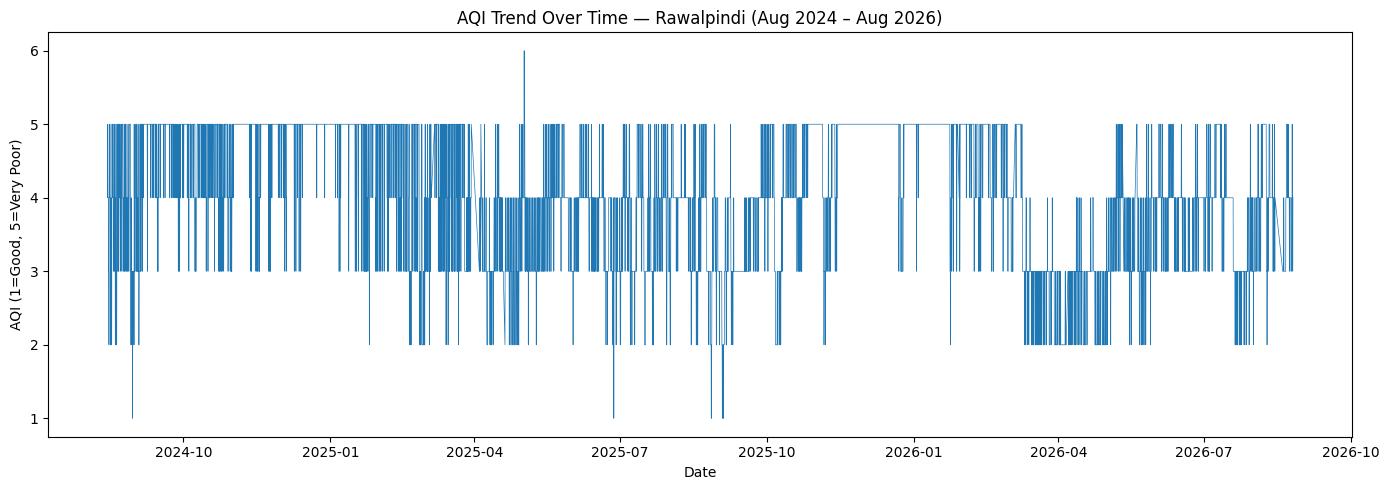

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(df["datetime"], df["aqi"], linewidth=0.5)
plt.title("AQI Trend Over Time — Rawalpindi (Aug 2024 – Aug 2026)")
plt.xlabel("Date")
plt.ylabel("AQI (1=Good, 5=Very Poor)")
plt.tight_layout()
plt.savefig("aqi_trend_over_time.png")
plt.show()

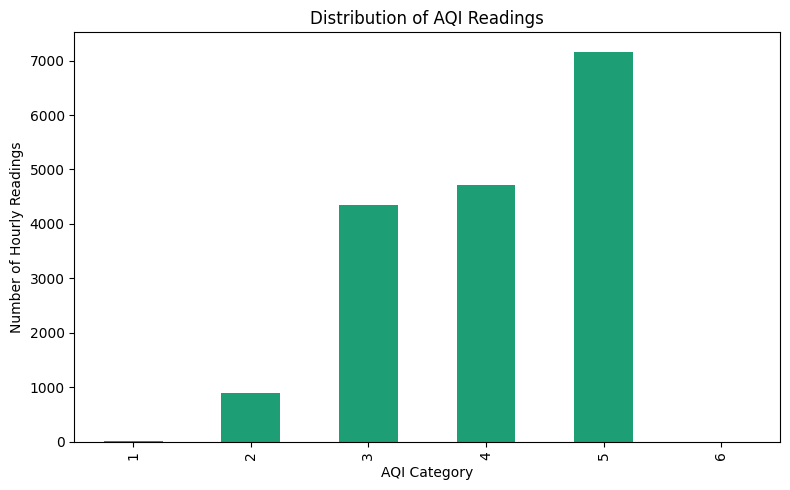

In [10]:
plt.figure(figsize=(8, 5))
df["aqi"].value_counts().sort_index().plot(kind="bar", color="#1D9E75")
plt.title("Distribution of AQI Readings")
plt.xlabel("AQI Category")
plt.ylabel("Number of Hourly Readings")
plt.tight_layout()
plt.savefig("aqi_distribution.png")
plt.show()

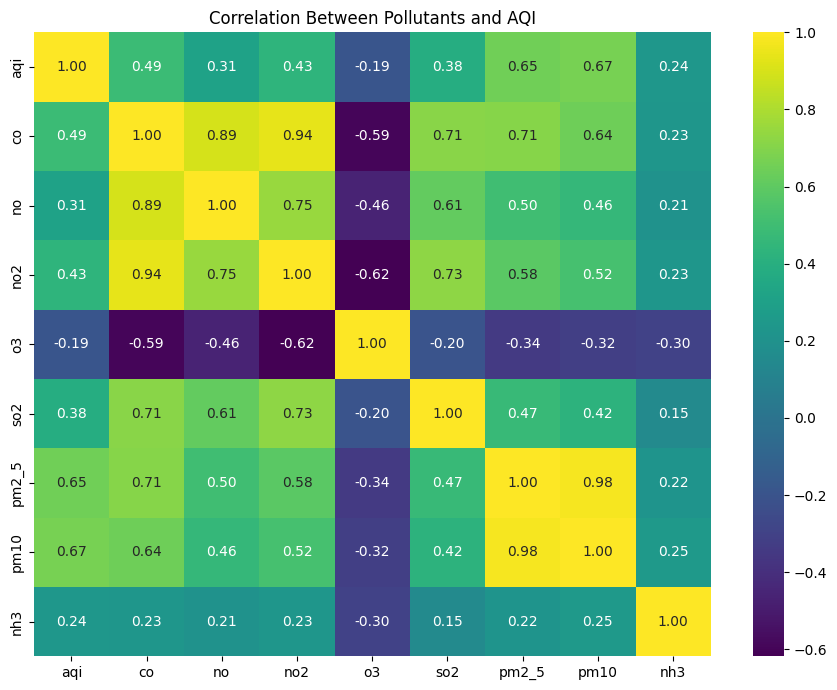

In [11]:
import seaborn as sns

pollutant_cols = ["aqi", "co", "no", "no2", "o3", "so2", "pm2_5", "pm10", "nh3"]
plt.figure(figsize=(9, 7))
sns.heatmap(df[pollutant_cols].corr(), annot=True, cmap="viridis", fmt=".2f")
plt.title("Correlation Between Pollutants and AQI")
plt.tight_layout()
plt.savefig("pollutant_correlation.png")
plt.show()

In [12]:
from google.colab import files
files.download("aqi_trend_over_time.png")
files.download("aqi_distribution.png")
files.download("pollutant_correlation.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>